## COMPAS - 2 OBJECTIVES

### Multi Layer Perceptron

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

In [17]:
from ml_moo import moo
from ml_moo import get_objectives, get_models
from ml_moo.analysis.visualization import plot_pareto_2d
from ml_moo.analysis.metrics import compute_hypervolume_progress

from scalarization import MLPScalarization

### Dataset and Model

In [18]:
# Setting a seed for reproducibility
seed = 42

In [19]:
import random
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [20]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [21]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [22]:
# Logistic Regression with equal weight to use as baseline model
equal = MLPScalarization(num_objs=2,
                        X=X_train, 
                        y=y_train, 
                        fair_feat=fair_feature,
                        #tol=tol, max_iter=max_iter
                        )
equal.optimize(np.array([0.5, 0.5]))

## MOLA

01:27:51 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
01:27:51 | DEBUG | ml_moo | Finding 1th individual minimum
01:27:52 | DEBUG | ml_moo | Finding 2th individual minimum
01:27:52 | DEBUG | ml_moo | Calculated weights: [0.61350972 0.38649028]
01:27:52 | DEBUG | ml_moo | Importance: 0.008721756238153133
01:27:52 | DEBUG | ml_moo | Global lower bound (y*): [0.59735305 0.59991716]
01:27:52 | DEBUG | ml_moo | Iteration 1
01:27:52 | DEBUG | ml_moo | Solutions list: [array([0.59735305, 0.62248374]), array([0.61156923, 0.59991716])]
01:27:52 | DEBUG | ml_moo | Calculated weights: [0.11825857 0.88174143]
01:27:52 | DEBUG | ml_moo | Importance: 0.0021291071553322383
01:27:52 | DEBUG | ml_moo | Global lower bound (y*): [0.59356488 0.59991716]
01:27:52 | DEBUG | ml_moo | Iteration 2
01:27:52 | DEBUG | ml_moo | Solutions list: [array([0.59356488, 0.60233188]), array([0.61156923, 0.59991716])]
01:27:52

new solution added [0.59356488 0.60233188]
solution dominated [0.59735305 0.62248374]
new solution added [0.59817287 0.59851779]
solution dominated [0.61156923 0.59991716]


01:27:52 | DEBUG | ml_moo | Calculated weights: [0.2989301 0.7010699]
01:27:52 | DEBUG | ml_moo | Importance: 0.0013192159106430717
01:27:52 | DEBUG | ml_moo | Global lower bound (y*): [0.59356488 0.59851779]
01:27:52 | DEBUG | ml_moo | Iteration 4
01:27:52 | DEBUG | ml_moo | Solutions list: [array([0.59376998, 0.60039514]), array([0.59817287, 0.59851779]), array([0.59356488, 0.60233188])]
01:27:52 | DEBUG | ml_moo | Calculated weights: [0.1789915 0.8210085]
01:27:52 | DEBUG | ml_moo | Importance: 0.0006392875188245828
01:27:52 | DEBUG | ml_moo | Global lower bound (y*): [0.59356488 0.59851779]
01:27:52 | DEBUG | ml_moo | Iteration 5
01:27:52 | DEBUG | ml_moo | Solutions list: [array([0.59465578, 0.59928456]), array([0.59376998, 0.60039514]), array([0.59817287, 0.59851779]), array([0.59356488, 0.60233188])]


new solution added [0.59376998 0.60039514]
new solution added [0.59465578 0.59928456]


01:27:53 | DEBUG | ml_moo | Calculated weights: [0.40885267 0.59114733]
01:27:53 | DEBUG | ml_moo | Importance: 0.000549501190005186
01:27:53 | DEBUG | ml_moo | Global lower bound (y*): [0.59356488 0.59839274]
01:27:53 | DEBUG | ml_moo | Iteration 6
01:27:53 | DEBUG | ml_moo | Solutions list: [array([0.59594524, 0.59839274]), array([0.59465578, 0.59928456]), array([0.59376998, 0.60039514]), array([0.59356488, 0.60233188])]
01:27:53 | DEBUG | ml_moo | Calculated weights: [0.25315467 0.74684533]
01:27:53 | DEBUG | ml_moo | Importance: 0.0003447546281672986
01:27:53 | DEBUG | ml_moo | Global lower bound (y*): [0.59320836 0.59839274]
01:27:53 | DEBUG | ml_moo | Iteration 7
01:27:53 | DEBUG | ml_moo | Solutions list: [array([0.59320836, 0.59932045]), array([0.59594524, 0.59839274]), array([0.59465578, 0.59928456])]
01:27:53 | DEBUG | ml_moo | Calculated weights: [0.45259362 0.54740638]
01:27:53 | DEBUG | ml_moo | Importance: 0.0006204247889815169
01:27:53 | DEBUG | ml_moo | Global lower bou

...

new solution added [0.58616477 0.59480118]
solution dominated [0.58650836 0.59520134]
new solution added [0.58671587 0.59430163]
solution dominated [0.58698789 0.59454298]


01:27:57 | DEBUG | ml_moo | Calculated weights: [0.36575887 0.63424113]
01:27:57 | DEBUG | ml_moo | Importance: 0.00020918617687493146
01:27:57 | DEBUG | ml_moo | Global lower bound (y*): [0.58574828 0.59430163]
01:27:57 | DEBUG | ml_moo | Iteration 50
01:27:57 | DEBUG | ml_moo | Solutions list: [array([0.58582661, 0.59481446]), array([0.58671587, 0.59430163]), array([0.58616477, 0.59480118]), array([0.58574828, 0.59558989])]


new solution added [0.58582661 0.59481446]
solution dominated [0.5861088  0.59552758]


01:27:58 | DEBUG | ml_moo | Calculated weights: [0.90390974 0.09609026]
01:27:58 | DEBUG | ml_moo | Importance: 7.368418078979033e-05
01:27:58 | DEBUG | ml_moo | Global lower bound (y*): [0.58574828 0.59421347]
01:27:58 | DEBUG | ml_moo | Iteration 51
01:27:58 | DEBUG | ml_moo | Solutions list: [array([0.58622388, 0.59421347]), array([0.58582661, 0.59481446]), array([0.58616477, 0.59480118]), array([0.58574828, 0.59558989])]


new solution added [0.58622388 0.59421347]
solution dominated [0.58671587 0.59430163]


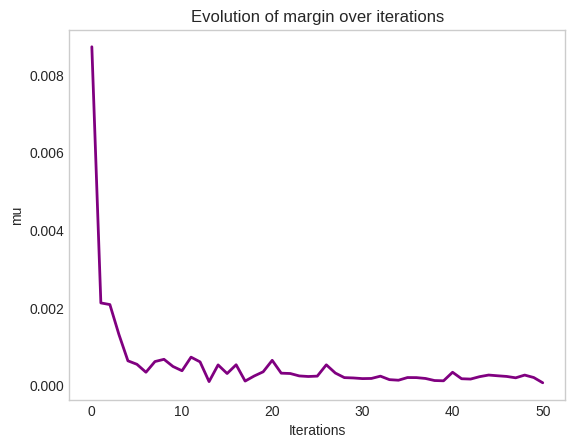

01:27:58 | INFO | ml_moo | Fit runtime: 6.10 seconds


In [23]:
method = 'mola'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [24]:
objs_all = np.array([s.objs for s in moopt.history_list])

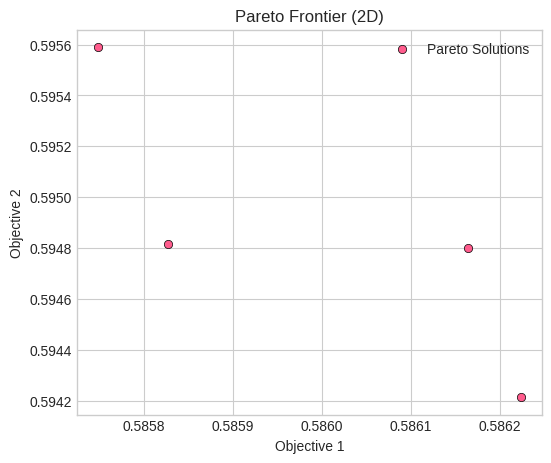

In [25]:
plot_pareto_2d(objs)

## Random Weight

In [26]:
method = 'random_weight'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

01:27:58 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeGap', 'nodeTimeLimit', 'targetGap'}
01:27:58 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
01:27:58 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
01:27:58 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima
01:27:58 | DEBUG | ml_moo.moo.random_weights | 3th solution
01:27:58 | DEBUG | ml_moo.moo.random_weights | 4th solution
01:27:58 | DEBUG | ml_moo.moo.random_weights | 5th solution
01:27:58 | DEBUG | ml_moo.moo.random_weights | 6th solution
01:27:58 | DEBUG | ml_moo.moo.random_weights | 7th solution
01:27:58 | DEBUG | ml_moo.moo.random_weights | 8th solution
01:27:59 | DEBUG | ml_moo.moo.random_weights | 9th solution
01:27:59 | DEBUG | ml_moo.moo.random_weights | 10th solution
01:27:59 | DEBUG | ml_moo.moo.random_weights | 11th solution
01:27:59 | DEBUG | ml_moo.moo.random_weights | 12th solution
01:27:59 | DEBUG | ml_moo.moo

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [27]:
from ml_moo.analysis.moo_analyzer import Analyzer

01:56:23 | WARNING | ml_moo | [Methods have different numbers of solutions: {4, 300}


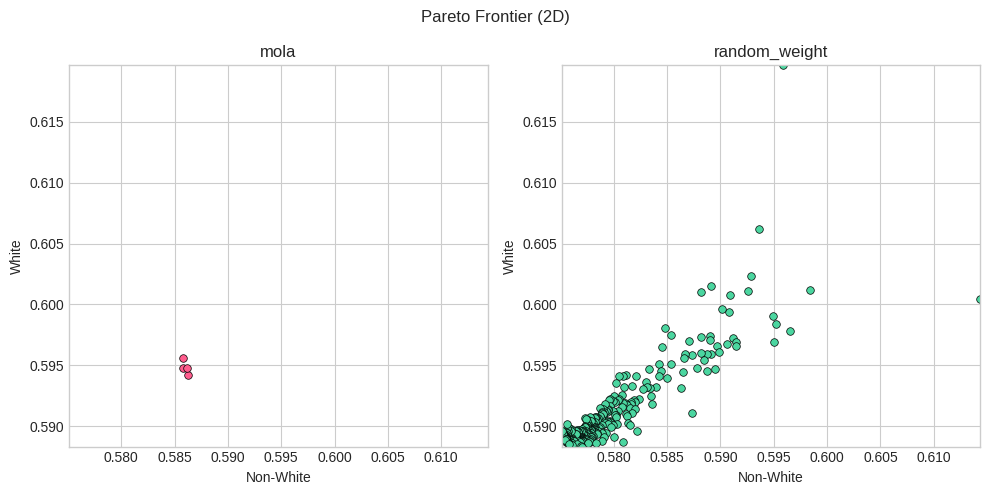

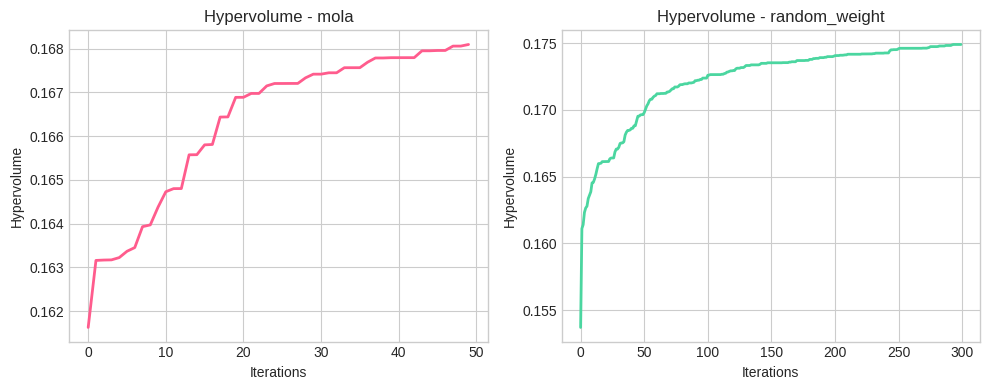

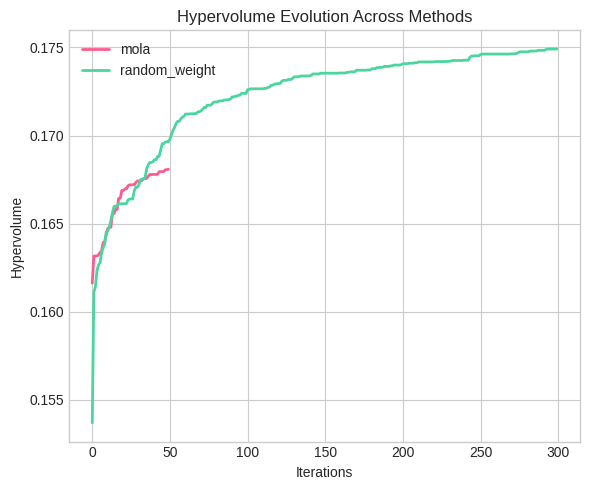

[Analyzer] Visualization complete.


In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["Non-White", "White"]
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      #point = equal.objs,
                      axis_label=axis_label
                      )

In [31]:
from ml_moo.analysis.visualization import plot_pareto_2d_set_limit

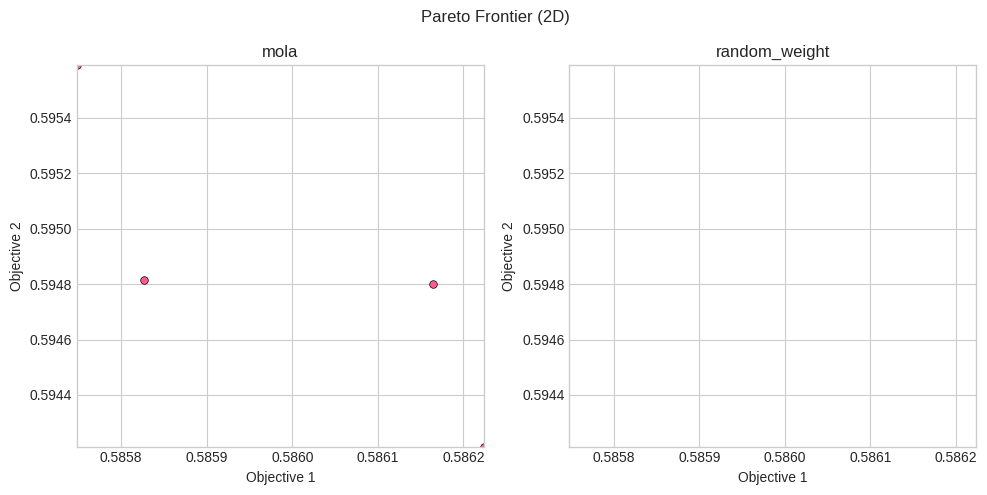

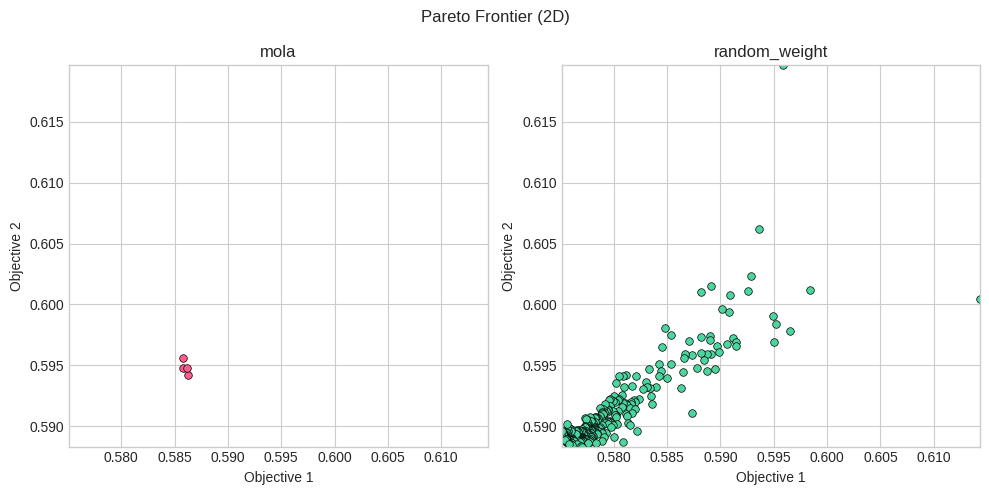

In [32]:
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 